# 01 · Neural Relation Operators — Toy Experiment

**Hypothesis**: A new composite relation can be learned from very few examples  
by initialising its operator as a composition of existing operators.

This notebook is a clean wrapper around `mre.knowledge_graph`.  
All model/training code lives in the package — the notebook only orchestrates.

## Experiment design

| Symbol | Relation | Meaning |
|--------|----------|---------|
| D | `depends_on` | theorem A's proof requires theorem B |
| G | `generalizes` | theorem A subsumes theorem B |
| E | `equivalent_to` | A and B are equivalent |
| P | `applied_in` | technique A is used in proof of B |

Composite (never seen during base training):
```
gen_dep = generalizes ∘ depends_on
```

Three strategies compared across k = {1, 5, 10, 25, 50, 100, full}:
1. **from_scratch** — random init, fine-tune on k examples  
2. **compose_fixed** — `f_gen ∘ f_dep`, no fine-tuning  
3. **compose_finetune** — compositional init → fine-tune on k examples  

In [1]:
# ── Environment setup ──────────────────────────────────────────────────────
import sys, os
# Make the package importable when running inside Kaggle or a notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import copy
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from mre.utils import load_config, resolve_device, set_seed, get_logger
from mre.knowledge_graph import (
    NROModel, SyntheticKG,
    hits_at_k, train_epoch, train_base_model,
)

# ── Config & reproducibility ───────────────────────────────────────────────
cfg    = load_config()                   # reads configs/kaggle_config.yaml
DEVICE = resolve_device(cfg)
set_seed(cfg.experiment.seed)
logger = get_logger('notebook_01')

print(f'Device : {DEVICE}')
print(f'Config : env={cfg.env}')

Device : cpu
Config : env=kaggle


## 1 · Synthetic Knowledge Graph

In [2]:
kg = SyntheticKG(
    num_entities = cfg.knowledge_graph.max_entities,
    embed_dim    = cfg.knowledge_graph.embed_dim,
    noise_std    = cfg.knowledge_graph.noise_std,
    seed         = cfg.experiment.seed,
)
print(kg.summary())

11:38:29  INFO      mre.knowledge_graph.synthetic_kg  SyntheticKG — 30000 entities, 4 base + 2 composite relations
SyntheticKG (entities=30000, dim=64)
  depends_on               : 400 edges
  generalizes              : 400 edges
  equivalent_to            : 400 edges
  applied_in               : 400 edges
  gen_dep                  : 400 edges
  indirect_dep             : 400 edges


## 2 · Phase 1 — Train Base Model on 4 Relations

In [3]:
BASE_RELATIONS = cfg.nro.base_relations

# Prepare splits
splits = {}
for rel in BASE_RELATIONS:
    train, val, test = kg.get_split(rel)
    splits[rel] = {'train': train, 'val': val, 'test': test}
    print(f'  {rel:20s}  train={len(train)}  val={len(val)}  test={len(test)}')

model = NROModel(
    num_entities   = kg.num_entities,
    relation_names = BASE_RELATIONS,
    embed_dim      = cfg.nro.embed_dim,
    hidden_dim     = cfg.nro.hidden_dim,
).to(DEVICE)

print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')

history = train_base_model(
    model,
    splits,
    BASE_RELATIONS,
    epochs     = cfg.nro.train_epochs,
    lr         = cfg.nro.learning_rate,
    weight_decay = cfg.nro.weight_decay,
    batch_size = cfg.nro.batch_size,
    hits_k     = cfg.experiment.hits_k,
)

print('\nFinal test Hits@10 (base relations):')
for rel in BASE_RELATIONS:
    h = hits_at_k(model, splits[rel]['test'], [rel], k=cfg.experiment.hits_k)
    print(f'  {rel:20s}: {h:.3f}')

  depends_on            train=280  val=60  test=60
  generalizes           train=280  val=60  test=60
  equivalent_to         train=280  val=60  test=60
  applied_in            train=280  val=60  test=60

Model parameters: 1,991,424
11:38:31  INFO      mre.knowledge_graph.training  Training base model — 100 epochs, 4 relations, joint batches
11:38:45  INFO      mre.knowledge_graph.training  Epoch  10/100  loss=0.0883  val_H@10=0.008
11:38:58  INFO      mre.knowledge_graph.training  Epoch  20/100  loss=0.0068  val_H@10=0.017
11:39:12  INFO      mre.knowledge_graph.training  Epoch  30/100  loss=0.0034  val_H@10=0.017
11:39:25  INFO      mre.knowledge_graph.training  Epoch  40/100  loss=0.0017  val_H@10=0.021
11:39:39  INFO      mre.knowledge_graph.training  Epoch  50/100  loss=0.0031  val_H@10=0.017
11:39:52  INFO      mre.knowledge_graph.training  Epoch  60/100  loss=0.0019  val_H@10=0.017
11:40:05  INFO      mre.knowledge_graph.training  Epoch  70/100  loss=0.0009  val_H@10=0.017
11:40

## 3 · Phase 2 — Composition Hypothesis Experiment

In [4]:
from mre.knowledge_graph.experiments import run_composition_experiment

comp_train, comp_val, comp_test = kg.get_split(cfg.experiment.composite_relation)
print(f'{cfg.experiment.composite_relation} — train:{len(comp_train)}  val:{len(comp_val)}  test:{len(comp_test)}')

results = run_composition_experiment(
    base_model       = model,
    comp_relation    = cfg.experiment.composite_relation,
    comp_chain       = cfg.experiment.composite_chain,
    train_pool       = comp_train,
    val_edges        = comp_val,
    test_edges       = comp_test,
    k_shots          = cfg.experiment.k_shots,
    n_trials         = cfg.experiment.n_trials,
    ft_epochs        = cfg.nro.finetune_epochs,
    ft_lr            = cfg.nro.finetune_lr,
    hits_k           = cfg.experiment.hits_k,
)

gen_dep — train:280  val:60  test:60
11:40:47  INFO      mre.knowledge_graph.experiments  Composition experiment: gen_dep = generalizes ∘ depends_on
11:40:47  INFO      mre.knowledge_graph.experiments    k = 1
11:40:48  INFO      mre.knowledge_graph.experiments      from_scratch            0.003 ± 0.007
11:40:49  INFO      mre.knowledge_graph.experiments      compose_fixed           0.017 ± 0.000
11:40:50  INFO      mre.knowledge_graph.nro_model  compose_init 'gen_dep': distillation loss = 0.001969
11:40:52  INFO      mre.knowledge_graph.nro_model  compose_init 'gen_dep': distillation loss = 0.001963
11:40:53  INFO      mre.knowledge_graph.nro_model  compose_init 'gen_dep': distillation loss = 0.001955
11:40:54  INFO      mre.knowledge_graph.nro_model  compose_init 'gen_dep': distillation loss = 0.001999
11:40:56  INFO      mre.knowledge_graph.nro_model  compose_init 'gen_dep': distillation loss = 0.001963
11:40:56  INFO      mre.knowledge_graph.experiments      compose_finetune       

## 4 · Results Summary

               Hits@10 by strategy and k-shot               
     k  from_scratch      compose_fixed     compose_finetune
------------------------------------------------------------
     1  0.003 ± 0.007     0.017 ± 0.000     0.017 ± 0.000     
     5  0.027 ± 0.013     0.017 ± 0.000     0.017 ± 0.000     
    10  0.017 ± 0.000     0.017 ± 0.000     0.017 ± 0.000     
    25  0.020 ± 0.007     0.017 ± 0.000     0.030 ± 0.007     
    50  0.033 ± 0.000     0.017 ± 0.000     0.027 ± 0.008     
   100  0.033 ± 0.018     0.017 ± 0.000     0.047 ± 0.012     
  full  0.110 ± 0.008     0.017 ± 0.000     0.117 ± 0.018     

Key finding (k=5):
  Compose+FT = 0.017   From scratch = 0.027
  Compose+FT@5 achieves 15.2% of full-data from-scratch
  ⚠  MIXED RESULTS


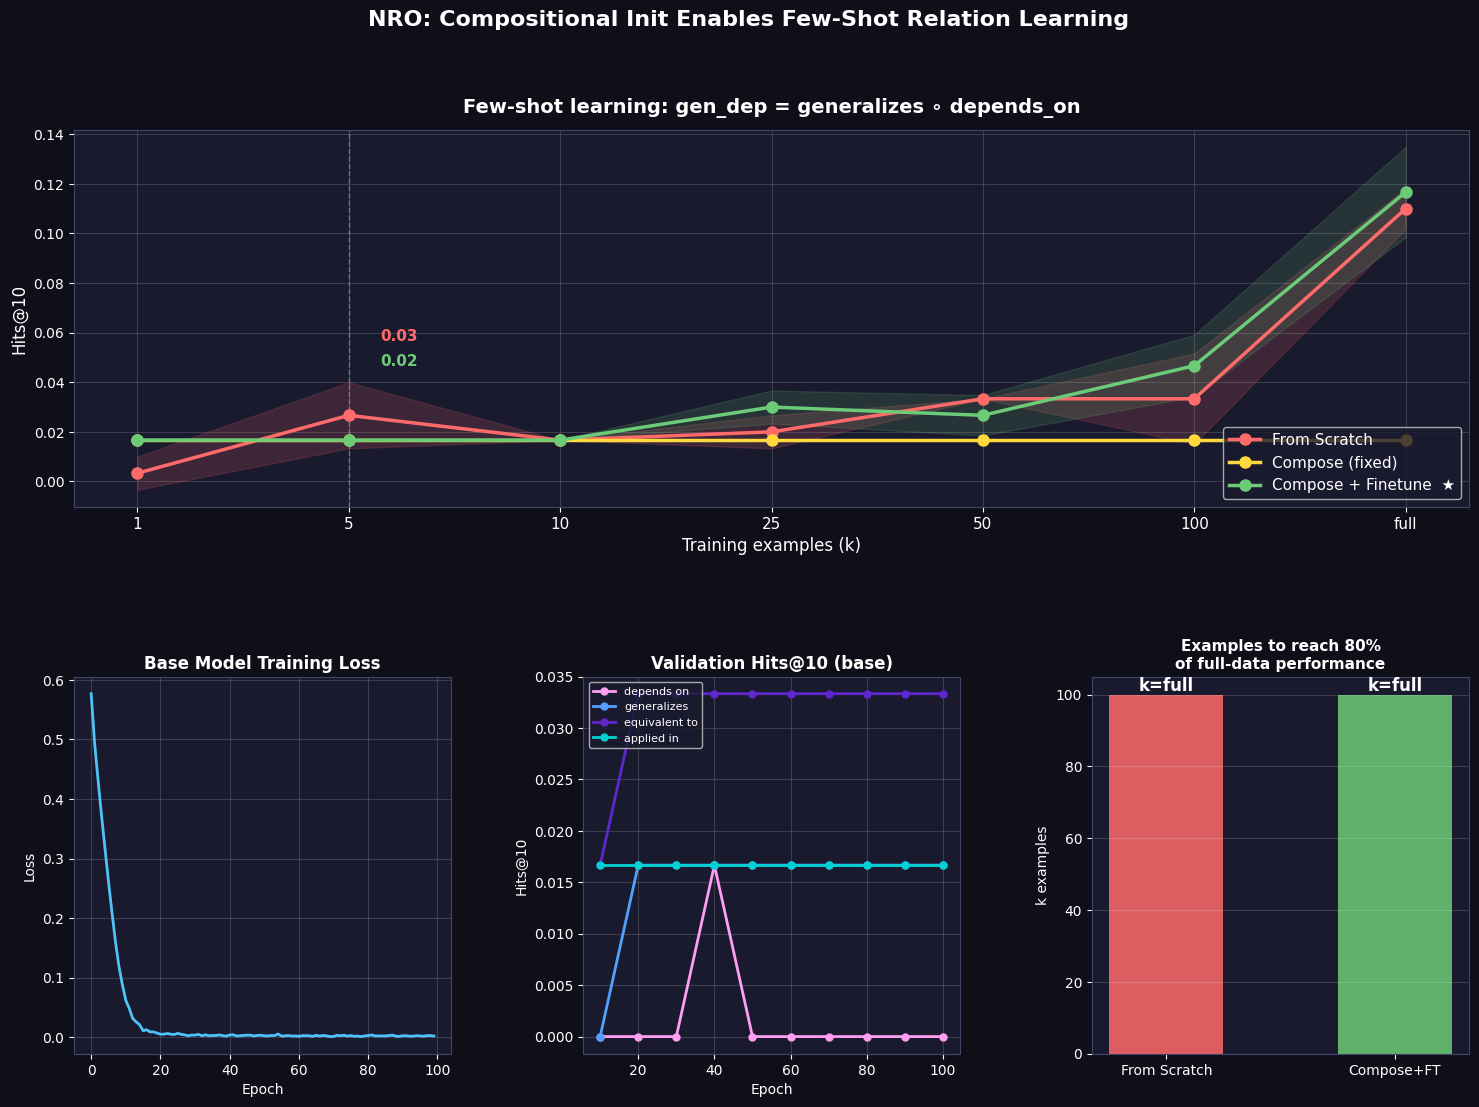

Figure saved to NRO_results.png


In [5]:
from mre.knowledge_graph.experiments import print_results_table, plot_results

print_results_table(results, cfg.experiment.k_shots)
fig = plot_results(results, history, cfg.experiment.k_shots)
fig.savefig('NRO_results.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Figure saved to NRO_results.png')

## 5 · Ablation — `indirect_dep = depends_on ∘ depends_on`

In [6]:
abl_train, abl_val, abl_test = kg.get_split('indirect_dep')

abl_results = run_composition_experiment(
    base_model    = model,
    comp_relation = 'indirect_dep',
    comp_chain    = ['depends_on', 'depends_on'],
    train_pool    = abl_train,
    val_edges     = abl_val,
    test_edges    = abl_test,
    k_shots       = [1, 5, 10, 50, 'full'],
    n_trials      = cfg.experiment.n_trials,
    ft_epochs     = cfg.nro.finetune_epochs,
    ft_lr         = cfg.nro.finetune_lr,
    hits_k        = cfg.experiment.hits_k,
)

print('\nAblation — indirect_dep:')
print_results_table(abl_results, [1, 5, 10, 50, 'full'])

11:45:12  INFO      mre.knowledge_graph.experiments  Composition experiment: indirect_dep = depends_on ∘ depends_on
11:45:12  INFO      mre.knowledge_graph.experiments    k = 1
11:45:14  INFO      mre.knowledge_graph.experiments      from_scratch            0.010 ± 0.008
11:45:15  INFO      mre.knowledge_graph.experiments      compose_fixed           0.017 ± 0.000
11:45:16  INFO      mre.knowledge_graph.nro_model  compose_init 'indirect_dep': distillation loss = 0.003133
11:45:17  INFO      mre.knowledge_graph.nro_model  compose_init 'indirect_dep': distillation loss = 0.003202
11:45:19  INFO      mre.knowledge_graph.nro_model  compose_init 'indirect_dep': distillation loss = 0.003100
11:45:20  INFO      mre.knowledge_graph.nro_model  compose_init 'indirect_dep': distillation loss = 0.003114
11:45:22  INFO      mre.knowledge_graph.nro_model  compose_init 'indirect_dep': distillation loss = 0.003186
11:45:22  INFO      mre.knowledge_graph.experiments      compose_finetune        0.017 ±

In [12]:
# ── Full diagnosis — run this entire block ────────────────────────────────────
import torch
import torch.nn.functional as F

device = next(model.parameters()).device
BASE_RELATIONS = ['depends_on', 'generalizes', 'equivalent_to', 'applied_in']

print("=" * 60)
print("DIAGNOSIS 1: Model parameter count vs data")
print("=" * 60)
n_params = sum(p.numel() for p in model.parameters())
n_train_total = sum(len(splits[r]['train']) for r in BASE_RELATIONS)
print(f"  Parameters   : {n_params:,}")
print(f"  Training edges: {n_train_total:,}")
print(f"  Ratio        : {n_params / n_train_total:.0f} params per training edge")
print(f"  (healthy range: < 100 params per edge)")

print()
print("=" * 60)
print("DIAGNOSIS 2: Training score vs test score")
print("=" * 60)
with torch.no_grad():
    for rel in BASE_RELATIONS:
        train_e = splits[rel]['train'][:30]
        test_e  = splits[rel]['test'][:30]

        h_tr = torch.tensor([h for h,_ in train_e], device=device)
        t_tr = torch.tensor([t for _,t in train_e], device=device)
        h_te = torch.tensor([h for h,_ in test_e],  device=device)
        t_te = torch.tensor([t for _,t in test_e],  device=device)

        train_pos = model.score(h_tr, [rel], t_tr).mean().item()
        test_pos  = model.score(h_te, [rel], t_te).mean().item()

        rand_t = torch.randint(0, kg.num_entities, (30,), device=device)
        train_neg = model.score(h_tr, [rel], rand_t).mean().item()

        print(f"  {rel:20s}  train_pos={train_pos:.3f}  test_pos={test_pos:.3f}  neg={train_neg:.3f}")
# If train_pos >> test_pos: overfitting confirmed
# If train_pos ≈ test_pos ≈ neg: model learned nothing at all

print()
print("=" * 60)
print("DIAGNOSIS 3: Operator gate values (how much each op transforms)")
print("=" * 60)
with torch.no_grad():
    for rel in BASE_RELATIONS:
        op   = model.operators[rel]
        gate = torch.sigmoid(op.gate).item()
        # Measure actual residual ratio on 20 random embeddings
        idx  = torch.randint(0, kg.num_entities, (20,), device=device)
        x    = model._entity_emb_normalized(idx)
        out  = op(x)
        ratio = (out - x).norm(dim=-1).mean().item()
        cos   = F.cosine_similarity(x, out).mean().item()
        print(f"  {rel:20s}  gate={gate:.3f}  residual_ratio={ratio:.3f}  cos={cos:.3f}")

print()
print("=" * 60)
print("DIAGNOSIS 4: Are entity embeddings diverse?")
print("=" * 60)
with torch.no_grad():
    N   = model.entity_emb.num_embeddings
    emb = F.normalize(model.entity_emb.weight, dim=-1)
    # Sample 200 pairs instead of full N×N
    idx_a = torch.randint(0, N, (1000,), device=device)
    idx_b = torch.randint(0, N, (1000,), device=device)
    mask  = idx_a != idx_b
    sims  = (emb[idx_a[mask]] * emb[idx_b[mask]]).sum(-1)
    print(f"  Entity count : {N}")
    print(f"  Mean pairwise cosine: {sims.mean().item():.4f}")
    print(f"  Std  pairwise cosine: {sims.std().item():.4f}")
    print(f"  Max  pairwise cosine: {sims.max().item():.4f}")
    print(f"  (healthy: mean≈0.00, std≈0.06-0.12, max<0.5)")

print()
print("=" * 60)
print("DIAGNOSIS 5: Ground-truth KG signal strength")
print("=" * 60)
with torch.no_grad():
    for rel in ['depends_on', 'generalizes']:
        sample = splits[rel]['train'][:50]
        gt_pred = torch.stack([kg._apply_transform(h, rel) for h,_ in sample])
        gt_tail = torch.stack([kg.true_entity_emb[t]       for _,t in sample])
        gt_rand = kg.true_entity_emb[torch.randint(0, N, (50,))]

        cos_sig  = F.cosine_similarity(gt_pred, gt_tail).mean().item()
        cos_rand = F.cosine_similarity(gt_pred, gt_rand).mean().item()
        print(f"  {rel:20s}  GT signal={cos_sig:.4f}  random={cos_rand:.4f}  gap={cos_sig-cos_rand:.4f}")
    print(f"  (gap > 0.15 means the task is learnable)")

print()
print("=" * 60)
print("DIAGNOSIS 6: Hits@10 on TRAINING set (memorization check)")
print("=" * 60)
from mre.knowledge_graph.training import hits_at_k
with torch.no_grad():
    for rel in BASE_RELATIONS:
        h_train = hits_at_k(model, splits[rel]['train'][:60], [rel], k=10)
        h_test  = hits_at_k(model, splits[rel]['test'],       [rel], k=10)
        print(f"  {rel:20s}  train_H@10={h_train:.3f}  test_H@10={h_test:.3f}")
# If train_H@10 >> test_H@10: clear overfitting
# If train_H@10 ≈ test_H@10 ≈ 0: model genuinely not learning

DIAGNOSIS 1: Model parameter count vs data
  Parameters   : 1,991,424
  Training edges: 1,120
  Ratio        : 1778 params per training edge
  (healthy range: < 100 params per edge)

DIAGNOSIS 2: Training score vs test score
  depends_on            train_pos=0.736  test_pos=-0.009  neg=-0.003
  generalizes           train_pos=0.719  test_pos=-0.000  neg=-0.002
  equivalent_to         train_pos=0.724  test_pos=-0.016  neg=0.002
  applied_in            train_pos=0.728  test_pos=0.008  neg=-0.006

DIAGNOSIS 3: Operator gate values (how much each op transforms)


AttributeError: 'NeuralRelationOperator' object has no attribute 'gate'

In [ ]:
# Check 2: Does the operator actually transform, or pass through?
with torch.no_grad():
    heads = torch.arange(20)
    head_emb = model.entity_emb(heads)
    after_op = model.operators['depends_on'](head_emb)

    # How different is the output from the input?
    residual_ratio = (after_op - head_emb).norm(dim=-1).mean() / head_emb.norm(dim=-1).mean()
    # Also check cosine sim between input and output
    passthrough_cos = F.cosine_similarity(head_emb, after_op).mean()

print(f"Operator residual ratio:  {residual_ratio:.4f}")
print(f"Input→Output cosine sim:  {passthrough_cos:.4f}")
# Healthy: ratio ≈ 0.3-0.8, cos ≈ 0.5-0.8
# Pass-through: ratio ≈ 0.0, cos ≈ 1.0  (shared residual dominates, MLP ignored)
# Inverted: cos < 0.0  (MLP overwhelms residual, destroying entity structure)